In [1]:
import math as m
import numpy as np
import scipy as sp

from obspy.core import UTCDateTime, read, Stream, Trace

from attitude_correction import Attitude
from utils import apply_att_corr

import matplotlib.pyplot as plt

import matplotlib.colors as colors
%matplotlib ipympl
%matplotlib inline

The attitude correction algorithm is described in datail in Lin et al. 2010, BSSA, 
https://doi.org/10.1785/0120090123<br>
Basically the following staps are implemented in the function attitude_correction.Attitude
1. From rotation rates $\dot\Theta_i$ , calculate Euler-angle sets $\Psi$ via
attitude equation ($S_x = sin(\Psi_x)$, $C_x = cos(\Psi_x)$, i denotes an axis in the body fixed coordinate system).
\begin{equation*}
\begin{pmatrix} 
    \dot\Psi_x(t) \\
    \dot\Psi_y(t) \\
    \dot\Psi_z(t)
\end{pmatrix}
= 
\begin{pmatrix} 
    1 & S_x tan(\Psi_y) & C_x tan(\Psi_y)\\
    0 & C_x & -S_x \\
    0 & S_x sec(\Psi_y) & C_x sec(\Psi_y)\\
\end{pmatrix}
\dot\Theta_i
\end{equation*}

2. Correct accelerometer outputs for centrifugal and
tilt-induced gravitational accelerations via the attitude correction equation, yielding translational velocity
in the body-attached frame. $f_i$ is the body frame accelerometer output.
\begin{equation*}
\ddot u_x = f_x - \dot \Theta_y \dot u_z + \dot \Theta_z \dot u_y + gS_y 
\end{equation*}
\begin{equation*}
\ddot u_y = f_y - \dot \Theta_z \dot u_x + \dot \Theta_x \dot u_z - gC_yS_x 
\end{equation*}
\begin{equation*}
\ddot u_z = f_z - \dot \Theta_x \dot u_y + \dot \Theta_y \dot u_x + g(1-C_yC_x) 
\end{equation*}

3. Construct the transformation matrix (a set of three Euler rotations) from
these Euler-angle sets, and transform these body-attached
frame velocities (P_B) into the global frame vector (P_G).
\begin{equation*}
P_G = 
\begin{pmatrix} 
    C_z & -S_z & 0\\
    S_z &  C_z & 0\\
    0   &  0   & 1\\
\end{pmatrix}
\begin{pmatrix} 
    C_y  & 0  & S_y\\
    0    & 1  & 0  \\
    -S_y & 0  & C_y\\
\end{pmatrix}
\begin{pmatrix} 
    1 &  0   &    0\\
    0 &  C_x & -S_x\\
    0 &  S_x &  C_x\\
\end{pmatrix}
P_B
\end{equation*}


4. Integrate these geographic-frame velocities to geographic-
frame displacements.


To understand the data we need to clarify positions and orientations of the stations and channels. The rotation rate channels are named according the the right-hand rule. 

<img src="structure_setup_CAD_sup.png" width=1050 height=1050 />


We start with defining some miniSeed identifiers

In [2]:
# path to the data folder
path = './data/'

# define some miniseed identifiers
net = 'XX'         # Network code
loc= ''            # Location code

# displacement transducers station codes
sta_DISP0 = 'DS00'
sta_DISP1 = 'DS01'
sta_DISP2 = 'DS02'

cha_disp = 'DXY'    # Channel code

# PCB accelerometers station codes
sta_ACC0 = 'AC00'
sta_ACC1 = 'AC01'
sta_ACC2 = 'AC02'

cha_acc = 'DNY'    # Channel code

# IMU50 station codes
sta_6C0 = '6C00'
sta_6C1 = '6C01'
sta_6C2 = '6C02'

# we take all 6 channels from the IMU50 data
cha_6C = 'D*'

Next we define the earth gravitational acceleration in m/s/s

In [3]:
one_g = 9.81

In the next cell you can choose the high-pass cut-off frequency applied for double integration

In [4]:
fmin = 0.5 # 1.0, 2.0
fmax = 50

Now, we define some event parameters like an event identifier, the start time in UTC and its diraation. We create a dictionary where we can store the maximum IDR and the permenent IDR for later analysis and plotting.

In [5]:
EV = {'eid':'92', 'ename':'#6', 'time':UTCDateTime('2023-06-23T05:01:56'), 'dt':59,
     'max_id_corr_2nd':0, 'max_id_ref_2nd':0, 'max_id_refa_2nd':0, 'max_id_rot_2nd':0,
     'max_id_corr_1st':0, 'max_id_ref_1st':0, 'max_id_refa_1st':0, 'max_id_rot_1st':0,
     'static_def_rot_1st':0, 'static_def_ref_1st':0, 'static_def_rot_2nd':0, 'static_def_ref_2nd':0}

Let's read the data.

In [6]:
evid = EV['eid']
utctime = EV['time']
dt = EV['dt']

YYYY = str(utctime.year)
DOY = str(utctime.julday).zfill(3)

st_DISP0 = read(path+net+'.'+sta_DISP0+'.'+loc+'.'+cha_disp+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)
st_DISP1 = read(path+net+'.'+sta_DISP1+'.'+loc+'.'+cha_disp+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)
st_DISP2 = read(path+net+'.'+sta_DISP2+'.'+loc+'.'+cha_disp+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)

st_ACC0 = read(path+net+'.'+sta_ACC0+'.'+loc+'.'+cha_acc+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)
st_ACC1 = read(path+net+'.'+sta_ACC1+'.'+loc+'.'+cha_acc+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)
st_ACC2 = read(path+net+'.'+sta_ACC2+'.'+loc+'.'+cha_acc+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)

st_6C0_raw = read(path+net+'.'+sta_6C0+'.'+loc+'.'+cha_6C+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)
st_6C1_raw = read(path+net+'.'+sta_6C1+'.'+loc+'.'+cha_6C+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)
st_6C2_raw = read(path+net+'.'+sta_6C2+'.'+loc+'.'+cha_6C+'.D.'+YYYY+'.'+DOY)#, starttime=utctime, endtime=utctime+dt)

Let's make sure that the PCB data and the IMU50 dara has the same sampling_rate:

In [7]:
do_resample = False
if st_6C0_raw[0].stats.sampling_rate != st_ACC0[0].stats.sampling_rate:
    do_resample = True
st_6C0 = st_6C0_raw.copy()
st_6C1 = st_6C1_raw.copy()
st_6C2 = st_6C2_raw.copy()
for tr in st_6C0:
    mean = np.mean(tr.data[:800])
    tr.data = tr.data-mean
if do_resample:
    st_6C0.filter('lowpass', freq = 100, corners=4, zerophase=True)
    st_6C0.resample(250)

for tr in st_6C1:
    mean = np.mean(tr.data[:800])
    tr.data = tr.data-mean
if do_resample:
    st_6C1.filter('lowpass', freq = 100, corners=4, zerophase=True)
    st_6C1.resample(250)

for tr in st_6C2:
    mean = np.mean(tr.data[:800])
    tr.data = tr.data-mean
if do_resample:
    st_6C2.filter('lowpass', freq = 100, corners=4, zerophase=True)
    st_6C2.resample(250)

The sampling rate is an important parameter, so let's extract it.

In [8]:
sps = st_ACC0[0].stats.sampling_rate

No we can start with the analysis. First we filter the data from the displacement transducers and from the PCB sensors.

In [9]:
st_DISP0_f = st_DISP0.copy()
st_DISP1_f = st_DISP1.copy()
st_DISP2_f = st_DISP2.copy()
st_DISP0_f.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
st_DISP1_f.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
st_DISP2_f.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

st_ACC0.detrend('linear')
st_ACC1.detrend('linear')
st_ACC2.detrend('linear')

st_ACC0_orig = st_ACC0.copy()
st_ACC1_orig = st_ACC1.copy()
st_ACC2_orig = st_ACC2.copy()

st_ACC0.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
st_ACC1.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
st_ACC2.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

3 Trace(s) in Stream:
XX.AC02..DNY | 2023-06-23T05:01:56.627500Z - 2023-06-23T05:02:55.623500Z | 250.0 Hz, 14750 samples
XX.AC02..DNY | 2023-06-23T05:01:56.627500Z - 2023-06-23T05:02:55.623500Z | 250.0 Hz, 14750 samples
XX.AC02..DNY | 2023-06-23T05:01:56.627500Z - 2023-06-23T05:02:55.623500Z | 250.0 Hz, 14750 samples

Next we perform the normal double integration on the PCB data. we subtrach the pre-event offset after each integration step.

In [10]:
st_vel0 = st_ACC0.copy()
for tr in st_vel0:
    mean = np.mean(tr.data[0:400])
    tr.data = tr.data - mean
st_vel0.integrate()
st_dis0 = st_vel0.copy()
for tr in st_dis0:
    mean = np.mean(tr.data[0:400])
    tr.data = tr.data - mean
st_dis0.integrate()


st_vel1 = st_ACC1.copy()
for tr in st_vel1:
    mean = np.mean(tr.data[0:400])
    tr.data = tr.data - mean
st_vel1.integrate()
st_dis1 = st_vel1.copy()
for tr in st_dis1:
    mean = np.mean(tr.data[0:400])
    tr.data = tr.data - mean
st_dis1.integrate()


st_vel2 = st_ACC2.copy()
for tr in st_vel2:
    mean = np.mean(tr.data[0:400])
    tr.data = tr.data - mean
st_vel2.integrate()
st_dis2 = st_vel2.copy()
for tr in st_dis2:
    mean = np.mean(tr.data[0:400])
    tr.data = tr.data - mean
st_dis2.integrate()

st_dis0.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
st_dis1.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
st_dis2.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

3 Trace(s) in Stream:
XX.AC02..DNY | 2023-06-23T05:01:56.627500Z - 2023-06-23T05:02:55.623500Z | 250.0 Hz, 14750 samples
XX.AC02..DNY | 2023-06-23T05:01:56.627500Z - 2023-06-23T05:02:55.623500Z | 250.0 Hz, 14750 samples
XX.AC02..DNY | 2023-06-23T05:01:56.627500Z - 2023-06-23T05:02:55.623500Z | 250.0 Hz, 14750 samples

Now we perform the attitude corrected double integration. Filter and baseline correction steps are exactely the same as in the normal double integration. 

In [11]:
# apply the correction
data_corr_0 = apply_att_corr(st_6C0, fmin, fmax, sps, one_g)
data_corr_1 = apply_att_corr(st_6C1, fmin, fmax, sps, one_g)
data_corr_2 = apply_att_corr(st_6C2, fmin, fmax, sps, one_g)

(
TAxGl0, TAyGl0, TAzGl0,
TVxGl0, TVyGl0, TVzGl0,
TDxGl0, TDyGl0, TDzGl0,
EAxGl0, EAyGl0, EAzGl0,
) = data_corr_0

(
TAxGl1, TAyGl1, TAzGl1,
TVxGl1, TVyGl1, TVzGl1,
TDxGl1, TDyGl1, TDzGl1,
EAxGl1, EAyGl1, EAzGl1,
) = data_corr_1

(
TAxGl2, TAyGl2, TAzGl2,
TVxGl2, TVyGl2, TVzGl2,
TDxGl2, TDyGl2, TDzGl2,
EAxGl2, EAyGl2, EAzGl2,
) = data_corr_2

Now we perform the single integration on the raw and unfiltered IMU50 rotation rate data. We also do a baseline correction.

In [12]:
for tr in st_6C0_raw:
    mean = np.mean(tr.data[:800])
    tr.data = tr.data-mean

for tr in st_6C1_raw:
    mean = np.mean(tr.data[:800])
    tr.data = tr.data-mean
 
for tr in st_6C2_raw:
    mean = np.mean(tr.data[:800])
    tr.data = tr.data-mean
    
st_6C0_raw_int = st_6C0_raw.select(channel='DJX').integrate()
st_6C1_raw_int = st_6C1_raw.select(channel='DJX').integrate()
st_6C2_raw_int = st_6C2_raw.select(channel='DJX').integrate()

In the next cell we assign more readable names to our variables in order not to get confused, when calculating the IDRs.

In [13]:
# let's assign all that values without getting confused:
disp_gndfloor_corr = TDyGl0
disp_1stfloor_corr = TDyGl1
disp_2ndfloor_corr = TDyGl2

disp_gndfloor_ref = st_DISP0[0].data * 1e-3
disp_1stfloor_ref = st_DISP1[0].data * 1e-3
disp_2ndfloor_ref = st_DISP2[0].data * 1e-3

disp_gndfloor_refa = st_dis0[0].data
disp_1stfloor_refa = st_dis1[0].data
disp_2ndfloor_refa = st_dis2[0].data

No we can calculate the IDRs

In [14]:
# calculate inter story drifts
id_corr_2nd = 100*(disp_2ndfloor_corr - disp_1stfloor_corr) / 1.78
id_ref_2nd = 100*(disp_2ndfloor_ref - disp_1stfloor_ref) / 1.78
id_refa_2nd = 100*(disp_2ndfloor_refa - disp_1stfloor_refa) / 1.78
id_rot_2nd = 100*st_6C2_raw_int.select(channel='DJX')[0].data

EV['max_id_ref_2nd'] = np.max(abs(id_ref_2nd))
idx_max_id_ref_2nd = np.argmax(abs(id_ref_2nd))

EV['max_id_corr_2nd'] = np.max(abs(id_corr_2nd))
idx_max_id_corr_2nd = np.argmax(abs(id_corr_2nd))

EV['max_id_refa_2nd'] = np.max(abs(id_refa_2nd))
idx_max_id_refa_2nd = np.argmax(abs(id_refa_2nd))

EV['max_id_rot_2nd'] = np.max(abs(id_rot_2nd))
idx_max_id_rot_2nd = np.argmax(abs(id_rot_2nd))

id_corr_1st = 100*(disp_1stfloor_corr - disp_gndfloor_corr) / 2.02
id_ref_1st = 100*(disp_1stfloor_ref - disp_gndfloor_ref) / 2.02
id_refa_1st = 100*(disp_1stfloor_refa - disp_gndfloor_refa) / 2.02
id_rot_1st = 100*st_6C1_raw_int.select(channel='DJX')[0].data

# scale
static_deform_rot_1st = np.mean(id_rot_1st[-600:]) - np.mean(id_rot_1st[:600])
static_deform_rot_2nd = np.mean(id_rot_2nd[-600:]) - np.mean(id_rot_2nd[:600])

static_deform_ref_1st = np.mean(id_ref_1st[-600:]) - np.mean(id_ref_1st[:600])
static_deform_ref_2nd = np.mean(id_ref_2nd[-600:]) - np.mean(id_ref_2nd[:600])

EV['static_def_rot_1st'] = static_deform_rot_1st
EV['static_def_ref_1st'] = static_deform_ref_1st
EV['static_def_rot_2nd'] = static_deform_rot_2nd
EV['static_def_ref_2nd'] = static_deform_ref_2nd

EV['max_id_ref_1st'] = np.max(abs(id_ref_1st))
idx_max_id_ref_1st = np.argmax(abs(id_ref_1st))

EV['max_id_corr_1st'] = np.max(abs(id_corr_1st))
idx_max_id_corr_1st = np.argmax(abs(id_corr_1st))

EV['max_id_refa_1st'] = np.max(abs(id_refa_1st))
idx_max_id_refa_1st = np.argmax(abs(id_refa_1st))

EV['max_id_rot_1st'] = np.max(abs(id_rot_1st))
idx_max_id_rot_1st = np.argmax(abs(id_rot_1st))

diff0c = ((id_ref_1st[:-1] - id_corr_1st))
diff1c = ((id_ref_2nd[:-1] - id_corr_2nd))

diff0nc = ((id_ref_1st[:] - id_refa_1st))
diff1nc = ((id_ref_2nd[:] - id_refa_2nd))

The rest is plotting.

In [15]:
# define some nice colors for plots:
c1 = (0.5,0.5,0.5)
c2 = (0.9, 0.6, 0)
c3 = (0.35, 0.7, 0.9)
c4 = (0, 0.6, 0.5)

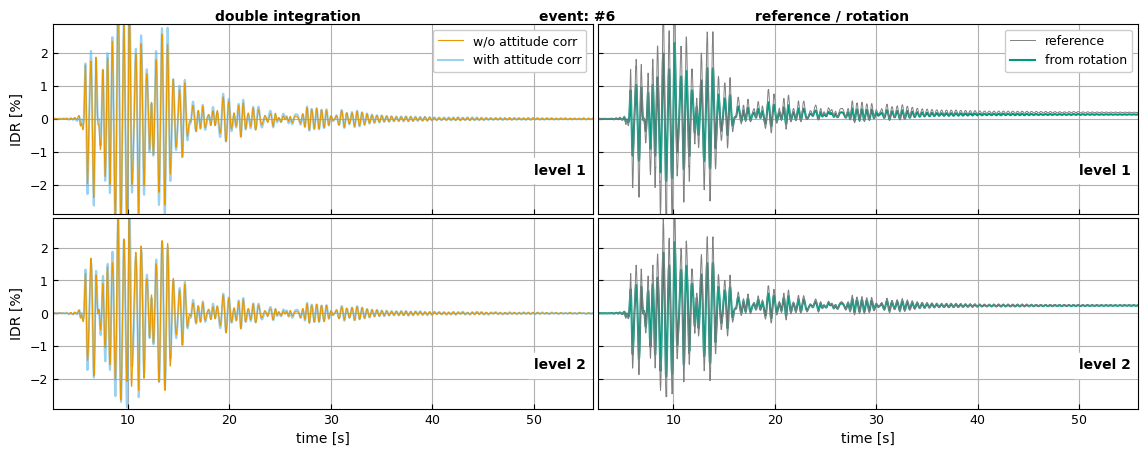

In [16]:
# define a time axis
sc = np.arange(0, st_DISP0[0].stats.npts, 1)*st_DISP0[0].stats.delta
sc_6C_raw = np.arange(0, st_6C0_raw[0].stats.npts, 1)*st_6C0_raw[0].stats.delta


fig_10, ax2 = plt.subplots(nrows=2, ncols=2, figsize=(14, 5),
                         gridspec_kw = {'wspace':0.01, 'hspace':0.02},)


line_id1_ro, = ax2[0][1].plot(sc_6C_raw[:], id_rot_1st, color=c4, linestyle='-', linewidth=1.5, label='from rotation')
line_id1_r, = ax2[0][1].plot(sc[:], id_ref_1st, color=c1, linestyle='-', linewidth=0.7, label='reference')

line_id1_c, = ax2[0][0].plot(sc[:-1], id_corr_1st, color=c3, linestyle='-', linewidth=1.5, alpha=0.6, label='with attitude corr')
line_id1_ra, = ax2[0][0].plot(sc[:], id_refa_1st, color=c2, linestyle='-', linewidth=0.8, label='w/o attitude corr')


line_id2_ro, = ax2[1][1].plot(sc_6C_raw[:], id_rot_2nd, color=c4, linestyle='-', linewidth=1.5, label='from rotation')
line_id2_r, = ax2[1][1].plot(sc[:], id_ref_2nd, color=c1, linestyle='-', linewidth=0.7)

line_id2_c, = ax2[1][0].plot(sc[:-1], id_corr_2nd, color=c3, linestyle='-', alpha=0.6, linewidth=1.5)
line_id2_ra, = ax2[1][0].plot(sc[:], id_refa_2nd, color=c2, linestyle='-', linewidth=0.8)


lines1 = (line_id1_r, line_id1_ro)
lines2 = (line_id1_ra, line_id1_c)

ax2[0][0].legend(handles=lines2, loc='upper right', fontsize=9, framealpha=1)
ax2[0][1].legend(handles=lines1, loc='upper right', fontsize=9, framealpha=1)

ax2[1][0].set_xlabel('time [s]')
ax2[1][1].set_xlabel('time [s]')
ax2[0][0].set_ylabel('IDR [%]')
ax2[1][0].set_ylabel('IDR [%]')

ax2[0][0].tick_params(axis='both', which='major', direction='in',
                     labelleft=True, labeltop=False, labelright=False, labelbottom=False, labelsize=9)
ax2[1][0].tick_params(axis='both', which='major', direction='in',
                     labelleft=True, labeltop=False, labelright=False, labelbottom=True, labelsize=9)
ax2[0][1].tick_params(axis='both', which='major', direction='in',
                     labelleft=False, labeltop=False, labelright=False, labelbottom=False, labelsize=9)
ax2[1][1].tick_params(axis='both', which='major', direction='in',
                     labelleft=False, labeltop=False, labelright=False, labelbottom=True, labelsize=9)


ax2[0][0].grid(visible=True)
ax2[1][0].grid(visible=True)
ax2[0][0].set_ylim(-2.9, 2.9)
ax2[1][0].set_ylim(-2.9, 2.9)
ax2[0][0].set_xlim(2.6, 55.8)
ax2[1][0].set_xlim(2.6, 55.8)
ax2[0][1].grid(visible=True)
ax2[1][1].grid(visible=True)
ax2[0][1].set_ylim(-2.9, 2.9)
ax2[1][1].set_ylim(-2.9, 2.9)
ax2[0][1].set_xlim(2.6, 55.8)
ax2[1][1].set_xlim(2.6, 55.8)


ax2[0][0].text(0.9, 1.015 , 'event: '+ EV['ename'], weight='bold', transform=ax2[0][0].transAxes)   
ax2[0][0].text(0.3, 1.015 , 'double integration', weight='bold', transform=ax2[0][0].transAxes)   
ax2[0][0].text(1.3, 1.015 , 'reference / rotation', weight='bold', transform=ax2[0][0].transAxes)   
ax2[0][0].text(50, -1.7 , 'level 1', weight='bold', backgroundcolor='w')
ax2[1][0].text(50, -1.7 , 'level 2', weight='bold', backgroundcolor='w')
ax2[0][1].text(50, -1.7 , 'level 1', weight='bold', backgroundcolor='w')
ax2[1][1].text(50, -1.7 , 'level 2', weight='bold', backgroundcolor='w')

plt.savefig('plots/waveformsIDR_static_evt'+evid+'_fmin'+str(fmin)[0]+'p'+str(fmin)[2]+'.png', dpi=300, bbox_inches='tight')
plt.show()